## 1. Imports and load data

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np  
import pandas as pd 
import plotly.graph_objs as go
import random
import seaborn as sns
import warnings
import urllib.parse


from scipy import stats
from wordfreq import zipf_frequency

from flow_tree_utils import generate_trajs_from_df, load_test_df, OBJECTS, generate_flow_tree_from_trajs, plot_flow_tree

### Load articles and categories

In [2]:
### Load articles and categories
data_path = "data/wikispeedia_paths-and-graph"

# load article names
article_names = []
with open(f"{data_path}/articles.tsv") as f:
    for line in f:
        line = line.strip()
        if len(line) == 0 or line[0] == "#": continue

        # decoded_line = urllib.parse.unquote(line)
        # maybe leave in URL encoding bc the 
        article_names.append(line)

# load shortest paths


def get_nth_category(category_string, n):
    category_list = category_string.split(".")
    if len(category_list) <= n:
        return pd.NA
    return category_list[n]

# load categories
column_names = ["article", "category"]
categories_df = pd.read_csv(f"{data_path}/categories.tsv", names=column_names, sep='\t', skiprows=[i for i in range(13)])
categories_df["num_categories"] = categories_df["category"].apply(lambda x: len(x.split(".")))
print("Max category depth is", categories_df["num_categories"].max())
for i in range(categories_df["num_categories"].max()):
    categories_df[f"category{i}"] = categories_df["category"].apply(lambda x: get_nth_category(x, i))
categories_df


Max category depth is 4


,article,category,num_categories,category0,category1,category2,category3
0,%C3%81ed%C3%A1n_mac_Gabr%C3%A1in,subject.History.British_History.British_Histor...,4,subject,History,British_History,British_History_1500_and_before_including_Roma...
1,%C3%81ed%C3%A1n_mac_Gabr%C3%A1in,subject.People.Historical_figures,3,subject,People,Historical_figures,<NA>
2,%C3%85land,subject.Countries,2,subject,Countries,<NA>,<NA>
3,%C3%85land,subject.Geography.European_Geography.European_...,4,subject,Geography,European_Geography,European_Countries
4,%C3%89douard_Manet,subject.People.Artists,3,subject,People,Artists,<NA>
...,...,...,...,...,...,...,...
5199,Zirconium,subject.Science.Chemistry.Chemical_elements,4,subject,Science,Chemistry,Chemical_elements
5200,Zoroaster,subject.People.Religious_figures_and_leaders,3,subject,People,Religious_figures_and_leaders,<NA>
5201,Zuid-Gelders,subject.Geography.European_Geography,3,subject,Geography,European_Geography,<NA>
5202,Zuid-Gelders,subject.Language_and_literature.Languages,3,subject,Language_and_literature,Languages,<NA>


### Load edges

In [3]:
# load links
column_names = ["linkSource", "linkTarget"]
edges_df = pd.read_csv(f"{data_path}/links.tsv", names=column_names, sep='\t', skiprows=[i for i in range(13)])
edge_dict = dict(zip(edges_df.linkSource, edges_df.linkTarget))

In [4]:
max_category_depth = categories_df["num_categories"].max()

category_level_dict = {}
for i in range(max_category_depth):
    for cat in categories_df[f"category{i}"].dropna():
        category_level_dict[cat] = i

for _, row in categories_df.iterrows():
    category_level_dict[row["article"]] = row["num_categories"]

edge_level_dict = {}
for k, v in edge_dict.items():
    if k not in category_level_dict or v not in category_level_dict:
        continue
    edge_level_dict[(k, v)] = category_level_dict[v] - category_level_dict[k]

### Load trajectories

In [5]:
def get_nth_article(article_string, n):
    article_list = article_string.split(";")
    return article_list[n]

def get_path_len(x):
    return len(x.split(";"))

def get_least_common_level(art1, art2):
    art1_row = categories_df[categories_df["article"]==art1]
    art2_row = categories_df[categories_df["article"]==art2]

    if len(art1_row) == 0 or len(art2_row) == 0: return None
    
    lcl = None
    for i in range(max_category_depth):
        art1_cat = art1_row[f"category{i}"].iloc[0]
        art2_cat = art2_row[f"category{i}"].iloc[0] # sometimes there are two categories got to fix

        if pd.isna(art1_cat) or pd.isna(art2_cat) or art1_cat != art2_cat:
            return lcl
        else:
            lcl = i
    return lcl

    # for i in range([f"category{i}"]
def get_levels_traj(x):
    articles = x.split(";")
    traj = []
    for i, article in enumerate(articles):
        if article == "<":
            # this means back click!
            for j in range(i-1, 0, -1):
                # sometimes more than one in a row
                if articles[j] != "<":
                    traj.append(category_level_dict.get(articles[j], None))
                    break
        else:
            traj.append(category_level_dict.get(article, None))
    return traj

def get_level_hops(x):
    articles = x.split(";")
    traj = []
    for i, article in enumerate(articles):
        if article == "<":
            # this means back click!
            for j in range(i-1, 0, -1):
                # sometimes more than one in a row
                if articles[j] != "<":
                    traj.append(articles[j])
                    break
        else:
            traj.append(article)

    lcls = []
    for i in range(len(traj)-1):
        a, b = traj[i], traj[i+1]
        lcls.append(get_least_common_level(a, b))
    return lcls


# load successful trajectories
column_names = ["hashedIpAddress", "timestamp", "durationInSec", "path", "rating"]
finished_trajs_df = pd.read_csv(f"{data_path}/paths_finished.tsv", names=column_names, sep='\t', skiprows=[i for i in range(16)])
finished_trajs_df["StartAt"] = finished_trajs_df["path"].apply(lambda x: get_nth_article(x, 0))
finished_trajs_df["EndAt"] = finished_trajs_df["path"].apply(lambda x: get_nth_article(x, -1))
finished_trajs_df["finished"] = True

# load unsuccessful trajectories
column_names = ["hashedIpAddress", "timestamp", "durationInSec", "path", "target", "type"]
unfinished_trajs_df = pd.read_csv(f"{data_path}/paths_unfinished.tsv", names=column_names, sep='\t', skiprows=[i for i in range(17)])
unfinished_trajs_df["StartAt"] = unfinished_trajs_df["path"].apply(lambda x: get_nth_article(x, 0))
unfinished_trajs_df["EndAt"] = unfinished_trajs_df["target"]
unfinished_trajs_df["finished"] = False

trajs_df = pd.concat([finished_trajs_df, unfinished_trajs_df])
trajs_df.reset_index()
trajs_df["traj_len"] = trajs_df["path"].apply(get_path_len)
trajs_df["levels_traj"] = trajs_df["path"].apply(get_levels_traj)
trajs_df["level_hops"] = trajs_df["path"].apply(get_level_hops)

trajs_df


,hashedIpAddress,timestamp,durationInSec,path,rating,StartAt,EndAt,finished,target,type,traj_len,levels_traj,level_hops
0,6a3701d319fc3754,1297740409,166,14th_century;15th_century;16th_century;Pacific...,NaN,14th_century,African_slave_trade,True,NaN,NaN,9,"[3, 3, 3, 3, 3, 3, 3, 4, 3]","[2, 2, 0, 2, 1, 2, 0, 1]"
1,3824310e536af032,1344753412,88,14th_century;Europe;Africa;Atlantic_slave_trad...,3.0,14th_century,African_slave_trade,True,NaN,NaN,5,"[3, 3, 3, 4, 3]","[0, 1, 0, 1]"
2,415612e93584d30e,1349298640,138,14th_century;Niger;Nigeria;British_Empire;Slav...,NaN,14th_century,African_slave_trade,True,NaN,NaN,8,"[3, 2, 2, 3, 3, 3, 4, 3]","[0, 3, 0, 0, 0, 0, 1]"
3,64dd5cd342e3780c,1265613925,37,14th_century;Renaissance;Ancient_Greece;Greece,NaN,14th_century,Greece,True,NaN,NaN,4,"[3, 3, 3, 4]","[2, 1, 0]"
4,015245d773376aab,1366730828,175,14th_century;Italy;Roman_Catholic_Church;HIV;R...,3.0,14th_century,John_F._Kennedy,True,NaN,NaN,7,"[3, 4, 3, 4, 3, 3, 3]","[0, 0, 0, 0, 0, 0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24870,109ed71f571d86e9,1389787605,180,Franz_Kafka;Tuberculosis;World_Health_Organiza...,NaN,Franz_Kafka,Cholera,False,Cholera,restart,8,"[3, 4, 3, 4, 2, 2, 3, 2]","[0, 0, 0, 0, 3, 1, 2]"
24871,232f992e57d43e8d,1389787697,6,Modern_history,NaN,Modern_history,Hollandic,False,Hollandic,restart,1,[3],[]
24872,2e09a7224600a7cd,1389798400,1900,Computer_programming;Linguistics;Culture;Popul...,NaN,Computer_programming,The_Beatles,False,The_Beatles,timeout,5,"[3, 3, 3, 3, 3]","[0, 0, 0, 2]"
24873,60af9e2138051b96,1389799481,1903,Jamaica;United_Kingdom;World_War_II;Battle_of_...,NaN,Jamaica,Alan_Turing,False,Alan_Turing,timeout,4,"[2, 3, 4, 3]","[0, 0, 1]"


### Process trajectories

In [6]:
# nodes need to be strings apparently
article_to_index = {article: str(i) for i, article in enumerate(article_names)}
index_to_article = {str(i): article for i, article in enumerate(article_names)}

def decode_path_to_traj(path):
    traj = []
    articles = path.split(";")
    for i, article in enumerate(articles):
        if article == "<":
            # this means back click!
            for j in range(i-1, 0, -1):
                # sometimes more than one in a row
                if articles[j] != "<":
                    traj.append(article_to_index[articles[j]])
                    break
        else:
            traj.append(article_to_index[article])
    return traj

trajs_df["traj"] = trajs_df["path"].apply(decode_path_to_traj) 
trajs_df["StartEnd"] = trajs_df["StartAt"] + "_" + trajs_df["EndAt"]

# don't want multiple attempts for each person
trajs_df = trajs_df.drop_duplicates(subset=["hashedIpAddress", "StartEnd"], keep="first")

trajs_df["avg_rating"] = trajs_df.groupby("StartEnd")["rating"].transform("mean")

trajs_df[["StartEnd", "traj", "avg_rating"]]


/var/folders/24/lp6939qs6f1d149198s_3mv40000gn/T/ipykernel_49817/204597507.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trajs_df["avg_rating"] = trajs_df.groupby("StartEnd")["rating"].transform("mean")


,StartEnd,traj,avg_rating
0,14th_century_African_slave_trade,"[10, 12, 15, 3134, 377, 105, 128, 379, 143]",3.0
1,14th_century_African_slave_trade,"[10, 1433, 128, 379, 143]",3.0
2,14th_century_African_slave_trade,"[10, 2982, 2984, 694, 3755, 128, 379, 143]",3.0
3,14th_century_Greece,"[10, 3464, 241, 1793]",NaN
4,14th_century_John_F._Kennedy,"[10, 2183, 3529, 1836, 3542, 3342, 2266]",3.0
...,...,...,...
24870,Franz_Kafka_Cholera,"[1585, 4247, 4538, 2614, 3223, 3223, 3917, 1696]",NaN
24871,Modern_history_Hollandic,[2802],NaN
24872,Computer_programming_The_Beatles,"[1008, 2478, 1098, 3315, 3315]",4.0
24873,Jamaica_Alan_Turing,"[2205, 4293, 4542, 506]",NaN


## 2. Set up how to run hypothesis test

1. Compute Flow Trees
2. Compute features on Flow Trees
3. Run appropriate statistical test


In [7]:
from scipy.spatial.distance import pdist
from scipy import stats 


def vector_statistic(x, y, axis):
    mean_x = np.mean(x, axis=axis)
    mean_y = np.mean(y, axis=axis)
        
    # Calculate Euclidean distance
    dist = mean_x - mean_y
    # print(f"Distance between means: {dist}")  # Debug print

    return dist

def run_ttest(group1_reps, group2_reps, statistic=vector_statistic):
    # Perform a t-test on groups
    t_stat, p_value = stats.ttest_ind(group1_reps, group2_reps)
    print(f"Group 1 mean: {np.mean(group1_reps):.2f} (var={np.var(group1_reps):.2f}; n={len(group1_reps)})")
    print(f"Group 2 mean: {np.mean(group2_reps):.2f} (var={np.var(group2_reps):.2f}; n={len(group2_reps)})")
    print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")

    # mean1, var1, n1 = np.mean(group1_reps), np.var(group1_reps), len(group1_reps)
    # mean2, var2, n2 = np.mean(group2_reps), np.var(group2_reps), len(group2_reps)
    # t = (mean1 - mean2) / np.sqrt((var1/n1 + var2/n2))
    # print("Number samples:", n1, n2)
    # print("T homemade:", t)

    return t_stat, p_value


def run_permutation_test(group1_reps, group2_reps, statistic=vector_statistic):
    res = stats.permutation_test((group1_reps, group2_reps), statistic, vectorized=True,
                       n_resamples=9999,# np.inf,
                       alternative='two-sided')
    print(f"Permutation test result: {res.statistic:.4} (p={res.pvalue:.4})")

    if len(group1_reps.shape) == 1:
        group1_reps = group1_reps.reshape(-1, 1)
    if len(group2_reps.shape) == 1:
        group2_reps = group2_reps.reshape(-1, 1)

    all_group_dist = pdist(np.concatenate([group1_reps, group2_reps]))

    within_group1_dist = pdist(group1_reps)
    within_group2_dist = pdist(group2_reps)
    within_group_dist = np.concatenate([within_group1_dist, within_group2_dist])

    print(f"Mean within group 1 dist: {np.mean(within_group1_dist):.2} (var={np.var(within_group1_dist):.2})")
    print(f"Mean within group 2 dist: {np.mean(within_group2_dist):.2} (var={np.var(within_group2_dist):.2})")
    print(f"Mean between all group dist: {np.mean(all_group_dist):.2} (var={np.var(all_group_dist):.2})")

    res2 = stats.permutation_test((within_group1_dist, all_group_dist), statistic, vectorized=True,
                       n_resamples=9999,#np.inf, 
                       alternative='less') # within group dist should be less than between
    print(f"Within group 1 dist vs among all: {res2.statistic:.4} (p={res2.pvalue:.4})")  
    t_stat, p_value = stats.ttest_ind(within_group1_dist, all_group_dist)
    print(f"\tT-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")  

    res2 = stats.permutation_test((within_group2_dist, all_group_dist), statistic, vectorized=True,
                       n_resamples=9999,#np.inf, 
                       alternative='less') # within group dist should be less than between
    print(f"Within group 2 dist vs among all: {res2.statistic:.4} (p={res2.pvalue:.4})")  
    t_stat, p_value = stats.ttest_ind(within_group2_dist, all_group_dist)
    print(f"\tT-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")  

    res2 = stats.permutation_test((within_group1_dist, within_group2_dist), statistic, vectorized=True,
                       n_resamples=9999,#np.inf, 
                       alternative='less') # within group dist should be less than between
    print(f"Within group 1 dist vs within group 2: {res2.statistic:.4} (p={res2.pvalue:.4})")  
    t_stat, p_value = stats.ttest_ind(within_group1_dist, within_group2_dist)
    print(f"\tT-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")   

def euc_dist_between_means(x, y):
    return np.linalg.norm(np.mean(x, axis=0) - np.mean(y, axis=0))


def run_homemade_permutation_test(group1, group2, statistic=euc_dist_between_means, n_permutations=9999):
    observed = statistic(group1, group2)

    data = np.concatenate([group1, group2])
    rng = np.random.default_rng()

    n_samples = len(data)

    n_group1 = len(group1)

    perm_generator = (rng.permutation(n_samples)
                            for i in range(n_permutations))

    def _batch_generator(iterable, batch):
        """A generator that yields batches of elements from an iterable"""
        iterator = iter(iterable)
        if batch <= 0:
            raise ValueError("`batch` must be positive.")
        z = [item for i, item in zip(range(batch), iterator)]
        while z:  # we don't want StopIteration without yielding an empty list
            yield z
            z = [item for i, item in zip(range(batch), iterator)]


    null_distribution = []
    for indices in _batch_generator(perm_generator, batch=n_permutations):
        indices = np.array(indices) # shape: [num permutations, num samples]

        for permutation in indices:
            data_batch = data[permutation, ...]

            permuted_group1 = data_batch[:n_group1, ...]
            permuted_group2 = data_batch[n_group1:, ...]

            permuted_statistic = statistic(permuted_group1, permuted_group2)
            null_distribution.append(permuted_statistic)

    null_distribution = np.array(null_distribution)

    adjustment = 1
    n_resamples = n_permutations

    def less(null_distribution, observed):
        cmps = null_distribution <= observed #+ gamma
        pvalues = (cmps.sum(axis=0) + adjustment) / (n_resamples + adjustment)
        return pvalues

    def greater(null_distribution, observed):
        cmps = null_distribution >= observed #- gamma
        pvalues = (cmps.sum(axis=0) + adjustment) / (n_resamples + adjustment)
        return pvalues

    def two_sided(null_distribution, observed):
        pvalues_less = less(null_distribution, observed)
        pvalues_greater = greater(null_distribution, observed)
        pvalues = np.minimum(pvalues_less, pvalues_greater) * 2
        return pvalues

    pvalue = two_sided(null_distribution, observed)
    # print(f"Permutation test: {observed:.4f} (p={pvalue:.4f})")

    return observed, pvalue    

## 3. Run hypothesis tests (refactor)

Steps:
1. Make groups
2. Run tests
3. Add results to df

Hypotheses tested:
1. Do quartiles have different group dynamics?
2. Do men and women have different group dynamics?

In [8]:
# Create a DataFrame to store hypothesis test results
def get_new_results_df():
    return pd.DataFrame(columns=[
        'hypothesis',
        'test_type',
        'group1_name',
        'group2_name',
        'group1_mean',
        'group2_mean',
        'group1_var',
        'group2_var',
        'group1_n',
        'group2_n',
        'statistic',
        'p_value',
        'significant',
        'metric',
        'notes'
    ])

all_results_df = get_new_results_df()

In [8]:
def get_heaviest_path(tree, root):    
    # Get all leaves (nodes with degree 1, excluding the root)
    leaves = [node for node in tree.nodes() if tree.degree(node) == 1 and node != root]
    # leaves = [node for node in tree.nodes() if tree.nodes[node].get("color", "white") in ["yellow", "green"]]

    def dfs(node, current_path, current_weight):
        nonlocal max_weight, heaviest_path
        
        # If we're at a leaf (degree 1 and not root)
        if node in leaves:
            if current_weight > max_weight:
                max_weight = current_weight
                heaviest_path = current_path.copy()
            return
            
        # Explore all children
        for neighbor in tree.neighbors(node):
            if neighbor not in current_path:  # Avoid cycles
                edge_weight = tree[node][neighbor]['weight']
                current_path.append(neighbor)
                dfs(neighbor, current_path, current_weight + edge_weight)
                current_path.pop()
    
    max_weight = float('-inf')
    heaviest_path = None
    dfs(root, [root], 0)
    
    return heaviest_path, max_weight, [tree[heaviest_path[i]][heaviest_path[i+1]]['weight'] for i in range(len(heaviest_path)-1)]

def extract_tree_features(graph, root):
    # Number of Nodes
    num_nodes = graph.number_of_nodes()
    
    # Tree Depth (Height)
    def tree_depth(graph, root):
        depths = nx.single_source_shortest_path_length(graph, root)
        return max(depths.values())
    
    depth = tree_depth(graph, root)
    
    # Diameter
    diameter = nx.diameter(graph)

    backbone_path, max_weight, weights = get_heaviest_path(graph, root)
    backbone_thickness = np.mean(weights) / max_weight
    
    # Number of Leaves
    num_leaves = sum(1 for node in graph.nodes() if graph.degree(node) == 1)
    
    # Branching Factor
    branching_factors = [len(list(graph.neighbors(node))) for node in graph.nodes()]
    avg_branching_factor = np.mean(branching_factors)
    
    # Put all features in a list
    features = [
        num_nodes,
        num_leaves,
        depth,
        avg_branching_factor,
        backbone_thickness,
        diameter
    ]
    
    return features

def compare_flow_tree_groups(results_df, group1_trees, group2_trees, normalise=False, include_embeddings=True, hypothesis_test_types=["permutation"], group1_name="Group 1", group2_name="Group 2", hypothesis=""):
    """Compare two groups of flow trees on various structural metrics.
    
    Args:
        results_df
        group1_trees: List of networkx graphs for first group
        group2_trees: List of networkx graphs for second group 
        group1_name: Name of first group for results
        group2_name: Name of second group for results
        hypothesis: Hypothesis being tested
        
    Returns:
        DataFrame containing test results
    """
    feature_names = ['num_nodes', 'num_leaves', 'depth',  'avg_branching_factor', 'backbone_thickness','diameter',]

    # Add embeddings to features arrays
    group1_features = np.array([extract_tree_features(G, 0) for G in group1_trees])
    group2_features = np.array([extract_tree_features(G, 0) for G in group2_trees])

    # Test each feature
    for i, feature_name in enumerate(feature_names):
        group1_feature = group1_features[:, i]
        group2_feature = group2_features[:, i]

        if normalise:
            # Normalize features to 0-1 range
            all_features = np.concatenate([group1_feature, group2_feature])
            feature_min = np.min(all_features)
            feature_max = np.max(all_features)
            
            # Avoid division by zero if min==max
            if feature_max > feature_min:
                group1_feature = (group1_feature - feature_min) / (feature_max - feature_min)
                group2_feature = (group2_feature - feature_min) / (feature_max - feature_min)
        
        if "t-test" in hypothesis_test_types:
            # T-test
            t_stat, p_val = stats.ttest_ind(group1_feature, group2_feature)
            results_df.loc[len(results_df)] = {
                'hypothesis': hypothesis,
                'test_type': 't-test',
                'group1_name': group1_name,
                'group2_name': group2_name,
                'group1_mean': np.mean(group1_feature),
                'group2_mean': np.mean(group2_feature),
                'group1_var': np.var(group1_feature),
                'group2_var': np.var(group2_feature),
                'group1_n': len(group1_feature),
                'group2_n': len(group2_feature),
                'statistic': t_stat,
                'p_value': p_val,
                'significant': p_val < 0.05,
                'metric': feature_name,
                'notes': f'Comparing flow tree {feature_name} between {group1_name} and {group2_name}'
            }

        if "permutation" in hypothesis_test_types:
            # Permutation test
            perm_stat, perm_p = run_homemade_permutation_test(group1_feature, group2_feature)
            results_df.loc[len(results_df)] = {
                'hypothesis': hypothesis,
                'test_type': 'permutation',
                'group1_name': group1_name,
                'group2_name': group2_name,
                'group1_mean': np.mean(group1_feature),
                'group2_mean': np.mean(group2_feature),
                'group1_var': np.var(group1_feature),
                'group2_var': np.var(group2_feature),
                'group1_n': len(group1_feature),
                'group2_n': len(group2_feature),
                'statistic': perm_stat,
                'p_value': perm_p,
                'significant': perm_p < 0.05,
                'metric': feature_name,
                'notes': f'Permutation test on flow tree {feature_name} between {group1_name} and {group2_name}'
            }

    if include_embeddings:
        # Initialize Graph2Vec embedder
        test_flow_tree_embedder = kc.Graph2Vec(dimensions=64)
        test_flow_tree_embedder.fit(group1_trees + group2_trees)

        # Get embeddings
        group1_embeddings = test_flow_tree_embedder.infer(group1_trees)
        group2_embeddings = test_flow_tree_embedder.infer(group2_trees)

        # Get PCA-1 and PCA-2 of embeddings?

        # Permutation test
        perm_stat, perm_p = run_homemade_permutation_test(group1_embeddings, group2_embeddings)
        results_df.loc[len(results_df)] = {
            'hypothesis': hypothesis,
            'test_type': 'permutation',
            'group1_name': group1_name,
            'group2_name': group2_name,
            'group1_mean': np.mean(group1_embeddings),
            'group2_mean': np.mean(group2_embeddings),
            'group1_var': np.var(group1_embeddings),
            'group2_var': np.var(group2_embeddings),
            'group1_n': len(group1_embeddings),
            'group2_n': len(group2_embeddings),
            'statistic': perm_stat,
            'p_value': perm_p,
            'significant': perm_p < 0.05,
            'metric': "graph2vec embeddings",
            'notes': f'Permutation test on flow tree {feature_name} between {group1_name} and {group2_name}'
        }

        group1_features = np.append(group1_features, np.mean(group1_embeddings, axis=1).reshape(-1, 1), axis=1)
        group2_features = np.append(group2_features, np.mean(group2_embeddings, axis=1).reshape(-1, 1), axis=1)
    
    return results_df, group1_features, group2_features


In [9]:
def get_heaviest_path(tree, root):    
    # Get all leaves (nodes with degree 1, excluding the root)
    leaves = [node for node in tree.nodes() if tree.degree(node) == 1 and node != root]
    # leaves = [node for node in tree.nodes() if tree.nodes[node].get("color", "white") in ["yellow", "green"]]

    def dfs(node, current_path, current_weight):
        nonlocal max_weight, heaviest_path
        
        # If we're at a leaf (degree 1 and not root)
        if node in leaves:
            if current_weight > max_weight:
                max_weight = current_weight
                heaviest_path = current_path.copy()
            return
            
        # Explore all children
        for neighbor in tree.neighbors(node):
            if neighbor not in current_path:  # Avoid cycles
                edge_weight = tree[node][neighbor]['weight']
                current_path.append(neighbor)
                dfs(neighbor, current_path, current_weight + edge_weight)
                current_path.pop()
    
    max_weight = float('-inf')
    heaviest_path = None
    dfs(root, [root], 0)
    
    return heaviest_path, max_weight, [tree[heaviest_path[i]][heaviest_path[i+1]]['weight'] for i in range(len(heaviest_path)-1)]

def extract_tree_features(graph, root):
    # Number of Nodes
    num_nodes = graph.number_of_nodes()
    
    # Tree Depth (Height)
    def tree_depth(graph, root):
        depths = nx.single_source_shortest_path_length(graph, root)
        return max(depths.values())
    
    depth = tree_depth(graph, root)
    
    # Diameter
    diameter = nx.diameter(graph)

    backbone_path, max_weight, weights = get_heaviest_path(graph, root)
    backbone_thickness = np.mean(weights) / max_weight
    
    # Number of Leaves
    num_leaves = sum(1 for node in graph.nodes() if graph.degree(node) == 1)
    
    # Branching Factor
    branching_factors = [len(list(graph.neighbors(node))) for node in graph.nodes()]
    avg_branching_factor = np.mean(branching_factors)
    
    # Put all features in a list
    features = [
        num_nodes,
        num_leaves,
        depth,
        avg_branching_factor,
        backbone_thickness,
        diameter
    ]
    
    return features

def compare_flow_tree_groups(results_df, group1_trees, group2_trees, normalise=False, include_embeddings=True, hypothesis_test_types=["permutation"], group1_name="Group 1", group2_name="Group 2", hypothesis=""):
    """Compare two groups of flow trees on various structural metrics.
    
    Args:
        results_df
        group1_trees: List of networkx graphs for first group
        group2_trees: List of networkx graphs for second group 
        group1_name: Name of first group for results
        group2_name: Name of second group for results
        hypothesis: Hypothesis being tested
        
    Returns:
        DataFrame containing test results
    """
    feature_names = ['num_nodes', 'num_leaves', 'depth',  'avg_branching_factor', 'backbone_thickness','diameter',]

    # Add embeddings to features arrays
    group1_features = np.array([extract_tree_features(G, 0) for G in group1_trees])
    group2_features = np.array([extract_tree_features(G, 0) for G in group2_trees])

    # Test each feature
    for i, feature_name in enumerate(feature_names):
        group1_feature = group1_features[:, i]
        group2_feature = group2_features[:, i]

        if normalise:
            # Normalize features to 0-1 range
            all_features = np.concatenate([group1_feature, group2_feature])
            feature_min = np.min(all_features)
            feature_max = np.max(all_features)
            
            # Avoid division by zero if min==max
            if feature_max > feature_min:
                group1_feature = (group1_feature - feature_min) / (feature_max - feature_min)
                group2_feature = (group2_feature - feature_min) / (feature_max - feature_min)
        
        if "t-test" in hypothesis_test_types:
            # T-test
            t_stat, p_val = stats.ttest_ind(group1_feature, group2_feature)
            results_df.loc[len(results_df)] = {
                'hypothesis': hypothesis,
                'test_type': 't-test',
                'group1_name': group1_name,
                'group2_name': group2_name,
                'group1_mean': np.mean(group1_feature),
                'group2_mean': np.mean(group2_feature),
                'group1_var': np.var(group1_feature),
                'group2_var': np.var(group2_feature),
                'group1_n': len(group1_feature),
                'group2_n': len(group2_feature),
                'statistic': t_stat,
                'p_value': p_val,
                'significant': p_val < 0.05,
                'metric': feature_name,
                'notes': f'Comparing flow tree {feature_name} between {group1_name} and {group2_name}'
            }

        if "permutation" in hypothesis_test_types:
            # Permutation test
            perm_stat, perm_p = run_homemade_permutation_test(group1_feature, group2_feature)
            results_df.loc[len(results_df)] = {
                'hypothesis': hypothesis,
                'test_type': 'permutation',
                'group1_name': group1_name,
                'group2_name': group2_name,
                'group1_mean': np.mean(group1_feature),
                'group2_mean': np.mean(group2_feature),
                'group1_var': np.var(group1_feature),
                'group2_var': np.var(group2_feature),
                'group1_n': len(group1_feature),
                'group2_n': len(group2_feature),
                'statistic': perm_stat,
                'p_value': perm_p,
                'significant': perm_p < 0.05,
                'metric': feature_name,
                'notes': f'Permutation test on flow tree {feature_name} between {group1_name} and {group2_name}'
            }

    if include_embeddings:
        # Initialize Graph2Vec embedder
        test_flow_tree_embedder = kc.Graph2Vec(dimensions=64)
        test_flow_tree_embedder.fit(group1_trees + group2_trees)

        # Get embeddings
        group1_embeddings = test_flow_tree_embedder.infer(group1_trees)
        group2_embeddings = test_flow_tree_embedder.infer(group2_trees)

        # Get PCA-1 and PCA-2 of embeddings?

        # Permutation test
        perm_stat, perm_p = run_homemade_permutation_test(group1_embeddings, group2_embeddings)
        results_df.loc[len(results_df)] = {
            'hypothesis': hypothesis,
            'test_type': 'permutation',
            'group1_name': group1_name,
            'group2_name': group2_name,
            'group1_mean': np.mean(group1_embeddings),
            'group2_mean': np.mean(group2_embeddings),
            'group1_var': np.var(group1_embeddings),
            'group2_var': np.var(group2_embeddings),
            'group1_n': len(group1_embeddings),
            'group2_n': len(group2_embeddings),
            'statistic': perm_stat,
            'p_value': perm_p,
            'significant': perm_p < 0.05,
            'metric': "graph2vec embeddings",
            'notes': f'Permutation test on flow tree {feature_name} between {group1_name} and {group2_name}'
        }

        group1_features = np.append(group1_features, np.mean(group1_embeddings, axis=1).reshape(-1, 1), axis=1)
        group2_features = np.append(group2_features, np.mean(group2_embeddings, axis=1).reshape(-1, 1), axis=1)
    
    return results_df, group1_features, group2_features


In [67]:
wikiG = nx.Graph()
wikiG.add_edges_from(zip(edges_df.linkSource, edges_df.linkTarget))

closeness_centrality = nx.closeness_centrality(wikiG)
print("closeness_centrality:", closeness_centrality)

closeness_centrality: {'%C3%81ed%C3%A1n_mac_Gabr%C3%A1in': 0.35405420543299, 'Columba': 0.3627088015471261, 'D%C3%A1l_Riata': 0.3632260128620154, 'Great_Britain': 0.47151398193718846, 'Ireland': 0.490374541214676, 'Isle_of_Man': 0.4503488812844731, 'Monarchy': 0.45992596653197115, 'Orkney': 0.42160937566503176, 'Picts': 0.3877708017893454, 'Scotland': 0.49712696089745423, 'Wales': 0.4542754344949193, '%C3%85land': 0.39793455653161086, '20th_century': 0.5040679375942414, 'Baltic_Sea': 0.4565825493285422, 'Crimean_War': 0.40813619016888203, 'Currency': 0.48375205321346487, 'Euro': 0.4545005908363621, 'European_Union': 0.4941267335227094, 'Finland': 0.4766114303905635, 'League_of_Nations': 0.4710779780496476, 'List_of_countries_by_system_of_government': 0.47552395357365906, 'Nationality': 0.41515772911601057, 'Parliamentary_system': 0.44653310872197316, 'Police': 0.45749370987399923, 'Russia': 0.5150530173396114, 'Stockholm': 0.40985089482052567, 'Sweden': 0.49815318995623864, 'Time_zone'

In [68]:
degree_centrality = nx.degree_centrality(wikiG)
print("Degree Centrality:", degree_centrality)

Degree Centrality: {'%C3%81ed%C3%A1n_mac_Gabr%C3%A1in': 0.0021781746896101066, 'Columba': 0.004356349379220213, 'D%C3%A1l_Riata': 0.00631670659986931, 'Great_Britain': 0.044216946199085165, 'Ireland': 0.07841428882596385, 'Isle_of_Man': 0.018296667392724897, 'Monarchy': 0.03811805706817687, 'Orkney': 0.011762143323894577, 'Picts': 0.008277063820518406, 'Scotland': 0.08582008277063821, 'Wales': 0.042474406447397084, '%C3%85land': 0.004138531910259203, '20th_century': 0.07993901110869092, 'Baltic_Sea': 0.019385754737529952, 'Crimean_War': 0.010890873448050535, 'Currency': 0.06512742321934219, 'Euro': 0.023524286647789154, 'European_Union': 0.06643432803310825, 'Finland': 0.044434763668046176, 'League_of_Nations': 0.026355913744282294, 'List_of_countries_by_system_of_government': 0.05532563711609671, 'Nationality': 0.008494881289479417, 'Parliamentary_system': 0.023306469178828143, 'Police': 0.020474842082335003, 'Russia': 0.12175996514920497, 'Stockholm': 0.012415595730777608, 'Sweden': 

In [69]:
betweenness_centrality = nx.betweenness_centrality(wikiG)
print("Betweenness Centrality:", betweenness_centrality)

Betweenness Centrality: {'%C3%81ed%C3%A1n_mac_Gabr%C3%A1in': 1.03123610335521e-06, 'Columba': 1.1521624788950728e-05, 'D%C3%A1l_Riata': 2.701782286931437e-05, 'Great_Britain': 0.0024108010081786988, 'Ireland': 0.0062183865831273695, 'Isle_of_Man': 0.0007160953771534171, 'Monarchy': 0.0008933079939856048, 'Orkney': 0.00020352802949341617, 'Picts': 6.809073244557776e-05, 'Scotland': 0.008528776918351855, 'Wales': 0.0021502283196126793, '%C3%85land': 3.878859113811596e-06, '20th_century': 0.008723574027976667, 'Baltic_Sea': 0.00045325252414481844, 'Crimean_War': 5.492490946236284e-05, 'Currency': 0.0014693849023757546, 'Euro': 0.00042682939492639317, 'European_Union': 0.002810915152991164, 'Finland': 0.0017925768550427288, 'League_of_Nations': 0.0003394163545402161, 'List_of_countries_by_system_of_government': 0.0006451094814095449, 'Nationality': 6.717461141644837e-05, 'Parliamentary_system': 0.00025274322752604243, 'Police': 0.00040304628839891516, 'Russia': 0.012781666777742085, 'Stock

In [70]:
trajs_df["closeness_centrality"] = trajs_df["StartAt"].map(closeness_centrality)

mean_closeness_centrality = np.mean(list(closeness_centrality.values()))

/var/folders/24/lp6939qs6f1d149198s_3mv40000gn/T/ipykernel_49817/3329318129.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trajs_df["closeness_centrality"] = trajs_df["StartAt"].map(closeness_centrality)


In [21]:
# find most common nodes
k = 100
most_common_start_nodes = trajs_df["StartAt"].value_counts()[:k].index.tolist()

print(f"Most common task is {most_common_start_nodes[0]} with {len(trajs_df[trajs_df['StartAt'] == most_common_start_nodes[0]]['traj'])} attempts.")
print(f"{k}th most common task is {most_common_start_nodes[-1]} with {len(trajs_df[trajs_df['StartAt'] == most_common_start_nodes[-1]]['traj'])} attempts")

reduced_trajs_df = trajs_df[trajs_df["StartAt"].isin(most_common_start_nodes)].copy()

Most common task is Brain with 2113 attempts.
100th most common task is Electron with 46 attempts


Group 1 mean: 6.23 (var=16.18; n=4543)
Group 2 mean: 5.92 (var=36.12; n=11410)
T-statistic: 3.2257, P-value: 0.0013
(0.3122409045669938, 0.0026)


/opt/miniconda3/envs/mazedyn-test/lib/python3.11/site-packages/karateclub/estimator.py:63: UserWarning: Please do be advised that the graph you have provided does not contain (some) edges in the main diagonal, for instance the self-loop constitued of (1, 1). These selfloops are necessary to ensure that the graph is traversable, and for this reason we create a copy of the graph and add therein the missing edges. Since we are creating a copy, this will immediately duplicate the memory requirements. To avoid this double allocation, you can provide the graph with the selfloops.
  warnings.warn(
/opt/miniconda3/envs/mazedyn-test/lib/python3.11/site-packages/karateclub/estimator.py:63: UserWarning: Please do be advised that the graph you have provided does not contain (some) edges in the main diagonal, for instance the self-loop constitued of (0, 0). These selfloops are necessary to ensure that the graph is traversable, and for this reason we create a copy of the graph and add therein the mi


Hypothesis Test Results:
                                                                         hypothesis    test_type    group1_name    group2_name  group1_mean  group2_mean  group1_var  group2_var  group1_n  group2_n     statistic  p_value  significant                metric                                                                                       notes
0   Flow Trees of top-half performers are different from those of bottom-half ones.       t-test  quartiles 1-2  quartiles 3-4     8.666667     8.666667    1.555556    1.555556      1554      5343  0.000000e+00   1.0000        False             num_nodes                       Comparing flow tree num_nodes between quartiles 1-2 and quartiles 3-4
1   Flow Trees of top-half performers are different from those of bottom-half ones.  permutation  quartiles 1-2  quartiles 3-4     8.666667     8.666667    1.555556    1.555556      1554      5343  0.000000e+00   0.0222         True             num_nodes             Permutation t

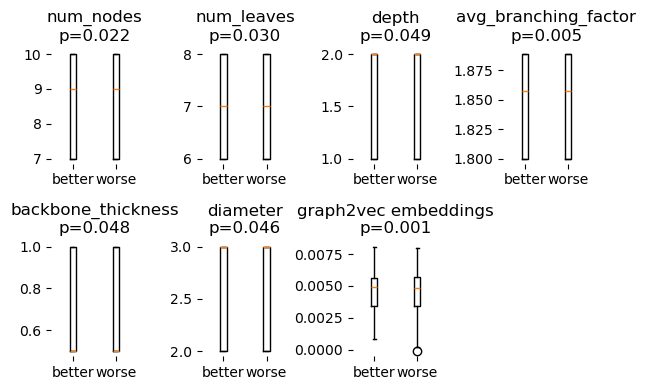

/var/folders/24/lp6939qs6f1d149198s_3mv40000gn/T/ipykernel_85141/2890906582.py:85: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_results_df = pd.concat([all_results_df, results_df], ignore_index=True)


In [29]:
import karateclub as kc
from sklearn.decomposition import PCA


# QUARTILES DIFFERENT
q12_flow_trees = []
q34_flow_trees = []

aa = []
bb = []

for (start_node, end_node), group in reduced_trajs_df.groupby(["StartAt", "EndAt"]):
    if group.index.empty: continue
    # group = group[group["accuracy"]]
    
    # q12_df = group[group["quartile"] <=2]
    # q34_df = group[group["quartile"] >=3]

    

    for i in range(3):
        sample_df1 = q12_df.sample(n=8, random_state=i) 

        trajs1 = np.array(sample_df1["traj"])
        G1 = generate_flow_tree_from_trajs(trajs1, END_NODE="0")
        new_G1 = nx.relabel.convert_node_labels_to_integers(G1, first_label=0, ordering='default')

        if group["closeness_centrality"].iloc[0] <= mean_closeness_centrality:

            q12_flow_trees.append(new_G1)
        else:
            q34_flow_trees.append(new_G1)

    if group["closeness_centrality"].iloc[0] <= mean_closeness_centrality:
        aa.extend(np.array(group["traj_len"]))
    else:
        bb.extend(np.array(group["traj_len"]))

    
    
    min_num_trajs = np.min([q12_df.shape[0], q34_df.shape[0]])

    

t_stat, p_value = stats.ttest_ind(aa, bb)
print(f"Group 1 mean: {np.mean(aa):.2f} (var={np.var(aa):.2f}; n={len(aa)})")
print(f"Group 2 mean: {np.mean(bb):.2f} (var={np.var(bb):.2f}; n={len(bb)})")
print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4f}")
print(run_homemade_permutation_test(aa, bb))


results_df = get_new_results_df()

# Run comparison on quartile groups
results_df, q12_features, q34_features = compare_flow_tree_groups(
    results_df,
    q12_flow_trees, 
    q34_flow_trees,
    group1_name="quartiles 1-2",
    group2_name="quartiles 3-4",
    hypothesis_test_types=["t-test", "permutation"],
    hypothesis="Flow Trees of top-half performers are different from those of bottom-half ones."
)

# Display results
print("\nHypothesis Test Results:")
print(results_df.to_string())

# Create visualization of results
plt.figure(figsize=(6, 4))
for i, feature_name in enumerate(results_df['metric'].unique()):
    feature_results = results_df[results_df['metric'] == feature_name]
    perm_result = feature_results[feature_results['test_type'] == 'permutation'].iloc[0]
    
    plt.subplot(2, 4, i+1)
    plt.boxplot([q12_features[:, i], q34_features[:, i]], 
                labels=['better', 'worse'])
    plt.title(f'{feature_name}\np={perm_result["p_value"]:.3f}')
    # if perm_result["significant"]:
        # plt.gca().set_facecolor('lightgreen')
    plt.box(on=None)
plt.tight_layout()
plt.show()

all_results_df = pd.concat([all_results_df, results_df], ignore_index=True)


1. aspects of graph structure
- centrality

2. start vs. end
- reverse 


is 2nd node more general than 1st node?


level of word based on usage / frequency


questions about semantics and questions about graph structure


alphabet (more specific vs more general)


r experienced people the backbone people or more specific? do they branch less? more successful?


branchiness of FT node vs semantic specificity of node

when do they take steps semantically closer? when do they backstep? why

how do people use wikipedia to do searches

## Node Flow Trees

In [11]:
# find most common nodes
k = 100
most_common_start_nodes = trajs_df["StartAt"].value_counts()[:k].index.tolist()

print(f"Most common task is {most_common_start_nodes[0]} with {len(trajs_df[trajs_df['StartAt'] == most_common_start_nodes[0]]['traj'])} attempts.")
print(f"{k}th most common task is {most_common_start_nodes[-1]} with {len(trajs_df[trajs_df['StartAt'] == most_common_start_nodes[-1]]['traj'])} attempts")

reduced_trajs_df = trajs_df[trajs_df["StartAt"].isin(most_common_start_nodes)].copy()

Most common task is Brain with 1807 attempts.
100th most common task is Water with 42 attempts


In [25]:
trajs_df.columns

Index(['hashedIpAddress', 'timestamp', 'durationInSec', 'path', 'rating',
       'StartAt', 'EndAt', 'finished', 'target', 'type', 'traj_len',
       'levels_traj', 'level_hops', 'traj', 'StartEnd', 'avg_rating'],
      dtype='object')

In [90]:
# process backclicks
all_trajectories = []
# flg=False
for path in trajs_df.path:
    # Longest backclick sequence is 15 <;<;<;<;<;<;<;<;<;<;<;<;<;<;< 
    assert ";<" * 16 not in path
    # print(path)
    for i in range(14, 0, -1):
        backtrack_seq = "<" + ";<"*i
        if backtrack_seq in path:
            # print(backtrack_seq, path)
            path = path.replace(backtrack_seq, f"<{i+1}")
            # print(path)
            flg=True

    split_path = path.split(";")
    real_nodes = []
    for i, node in enumerate(split_path):
        if "<" in node:
            bktrk = 1 if node == "<" else int(node[1:])
            node = real_nodes[i-bktrk-1]
        real_nodes.append(node)

    all_trajectories.append(real_nodes)


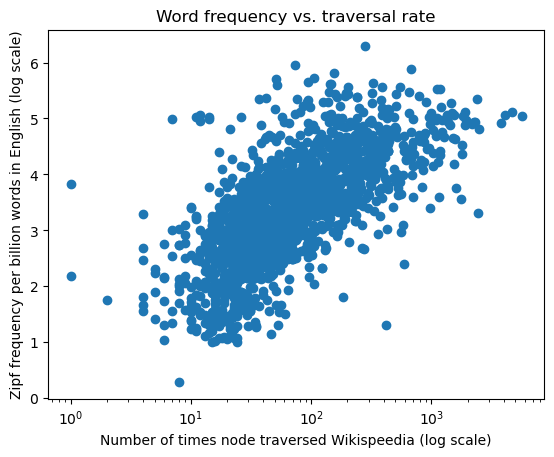

Zipf correlation: 0.684, p=0.000


In [135]:
from scipy.stats import pearsonr, norm

node_counts = {}
for trajectory in all_trajectories:
    for node in trajectory:
        node_counts[node] = node_counts.get(node, 0) + 1

sorted_nodes = sorted(node_counts.keys(), key=lambda x: node_counts[x], reverse=True)

wikispeedia_counts, zipf_frequencies = [], []
for node in sorted_nodes:
    # print(node, zipf_frequency(node, "en"))
    zf = zipf_frequency(node, "en")
    if zf > 0:
        wikispeedia_counts.append(node_counts[node])
        zipf_frequencies.append(zf)


plt.scatter(wikispeedia_counts, zipf_frequencies)
plt.xscale("log")
plt.xlabel("Number of times node traversed Wikispeedia (log scale)")
plt.ylabel("Zipf frequency per billion words in English (log scale)")
plt.title("Word frequency vs. traversal rate")
plt.show()

corr_zipf, p_value_zipf = pearsonr(np.log(wikispeedia_counts), zipf_frequencies)
print(f"Zipf correlation: {corr_zipf:.3f}, p={p_value_zipf:.3f}")

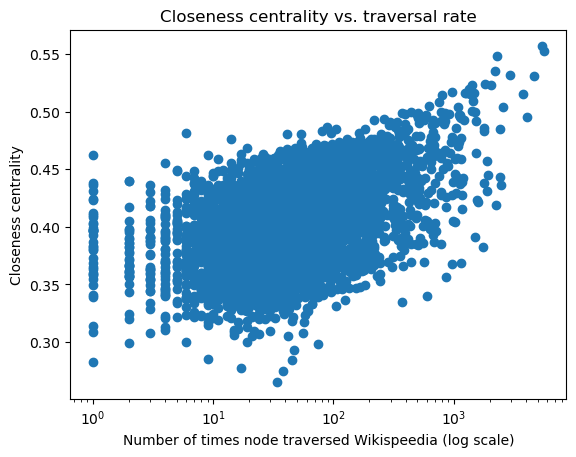

Closeness centrality correlation: 0.486, p=0.000


In [ ]:
wikispeedia_counts, closeness_centralities = [], []
for node in sorted_nodes:
    if node not in closeness_centrality: continue
    if (node_counts[node] > 10000) or (node_counts[node] < 1): continue
    wikispeedia_counts.append(node_counts[node])
    closeness_centralities.append(closeness_centrality[node])


plt.scatter(wikispeedia_counts, closeness_centralities)
plt.xscale("log")
plt.xlabel("Number of times node traversed Wikispeedia (log scale)")
plt.ylabel("Closeness centrality")
plt.title("Closeness centrality vs. traversal rate")
plt.show()

corr_close, p_value_close = pearsonr(np.log(wikispeedia_counts), closeness_centralities)
print(f"Closeness centrality correlation: {corr_close:.3f}, p={p_value_close:.3f}")

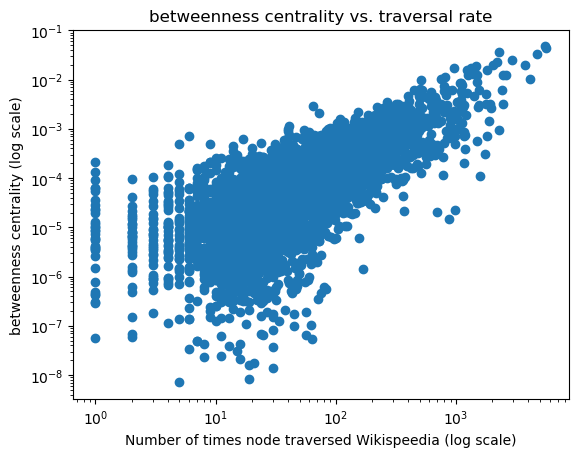

Betweenness centrality correlation: 0.688, p=0.000


In [100]:
wikispeedia_counts, betweenness_centralities = [], []
for node in sorted_nodes:
    if node not in betweenness_centrality: continue
    if node_counts[node] > 10000: continue
    if betweenness_centrality[node] == 0: continue
    wikispeedia_counts.append(node_counts[node])
    betweenness_centralities.append(betweenness_centrality[node])


plt.scatter(wikispeedia_counts, betweenness_centralities)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Number of times node traversed Wikispeedia (log scale)")
plt.ylabel("betweenness centrality (log scale)")
plt.title("betweenness centrality vs. traversal rate")
plt.show()

corr_between, p_value_between = pearsonr(np.log(wikispeedia_counts), np.log(betweenness_centralities))
print(f"Betweenness centrality correlation: {corr_between:.3f}, p={p_value_between:.3f}")

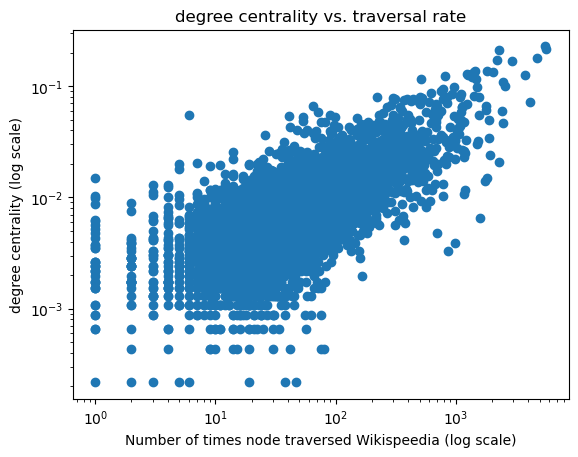

Degree centrality correlation: 0.688, p=0.000


In [101]:
wikispeedia_counts, degree_centralities = [], []
for node in sorted_nodes:
    if node not in degree_centrality: continue
    if node_counts[node] > 10000: continue
    wikispeedia_counts.append(node_counts[node])
    degree_centralities.append(degree_centrality[node])


plt.scatter(wikispeedia_counts, degree_centralities)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Number of times node traversed Wikispeedia (log scale)")
plt.ylabel("degree centrality (log scale)")
plt.title("degree centrality vs. traversal rate")
plt.show()

corr_degree, p_value_degree = pearsonr(np.log(wikispeedia_counts), np.log(degree_centralities))
print(f"Degree centrality correlation: {corr_degree:.3f}, p={p_value_degree:.3f}")

In [133]:
def steiger_z_test(r12, r13, r23, n, alternative="two-sided"):
    # Steiger's Z formula for comparing two dependent correlations
    # compares corr 1-2 vs. corr 1-3

    if n < 4:
        raise ValueError("Sample size must be at least 4")

    z_num = (r12 - r13) * np.sqrt((n - 3) * (1 + r23))
    z_denom = 2 * (1 - r12**2 - r13**2 - r23**2 + 2 * r12 * r13 * r23)
    z_denom = np.sqrt(z_denom)

    if z_denom == 0:
        raise ValueError("Denominator is zero — check your correlations.")

    z = z_num / z_denom

    # Choose p-value based on test direction
    if alternative == 'two-sided':
        p = 2 * (1 - norm.cdf(abs(z)))
    elif alternative == 'greater':  # r12 > r13
        p = 1 - norm.cdf(z)
    elif alternative == 'less':     # r12 < r13
        p = norm.cdf(z)
    else:
        raise ValueError("alternative must be 'two-sided', 'greater', or 'less'")

    return z, p


wikispeedia_counts, zipf_frequencies, betweenness_centralities = [], [], []
for node in sorted_nodes:
    zf = zipf_frequency(node, "en")
    if zf == 0: continue
    if node not in betweenness_centrality: continue
    if node_counts[node] > 10000: continue
    if betweenness_centrality[node] == 0: continue

    wikispeedia_counts.append(node_counts[node])
    zipf_frequencies.append(zf)
    betweenness_centralities.append(betweenness_centrality[node])


r12, _ = pearsonr(np.log(wikispeedia_counts), zipf_frequencies)
r13, _ = pearsonr(np.log(wikispeedia_counts), np.log(betweenness_centralities))
r23, _ = pearsonr(zipf_frequencies, np.log(betweenness_centralities))

# Testing: is r12 < r13? (i.e. is x2= zipf_frequencies LESS correlated with accuracies than x3 = betweenness_centralities?)
z, p = steiger_z_test(r12, r13, r23, n=len(wikispeedia_counts), alternative="less")
print(f"r12={r12:.3f}, r13={r13:.3f}, r23={r23:.3f}")
print(f"Z={z:0.5f}, p={p:0.5f}")

r12=0.684, r13=0.746, r23=0.611
Z=-4.66964, p=0.00000


### Start vs. End

including intermediate nodes

In [112]:
topk_nodes = sorted_nodes[:100]

In [125]:
## Make node trees for everything
# Create empty DataFrame to store all tree information
all_tree_df = pd.DataFrame(columns=[
    'node',           # the actual node label
    'trees'           # list of bootstrapped trees
])

example_tree_by_start_node = {}


traj_dict = {x: [] for x in topk_nodes}
for traj in all_trajectories:
    for i in range(len(traj)-8): # want min path length 7?
        if traj[i] in topk_nodes:
            traj_dict[traj[i]].append(traj[i:i+7])
print (traj_dict)
# k_fold = 20
for node in traj_dict:
    trees = []
    # for _ in range(k_fold):
    sampled_trajs = traj_dict[node]
    # print(len(sampled_trajs))
    if len(sampled_trajs) > 50:
        sampled_indices = np.random.choice(len(sampled_trajs), size=50, replace=False)
        sampled_trajs = [sampled_trajs[i] for i in sampled_indices]
    else:
        print(len(sampled_trajs))
    G = generate_flow_tree_from_trajs(sampled_trajs, END_NODE="1")
    new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default')
    trees.append(new_G)
        
    example_tree_by_start_node[node] = trees[0]

    all_tree_df = pd.concat([all_tree_df, pd.DataFrame({
        'node': [(node,)] * len(trees), 
        'trees': trees
    })], ignore_index=True)

all_tree_df

{'United_States': [['United_States', 'Walt_Whitman', 'United_States', 'Poetry_of_the_United_States', 'United_States', 'French_Revolution', 'Age_of_Enlightenment'], ['United_States', 'Poetry_of_the_United_States', 'United_States', 'French_Revolution', 'Age_of_Enlightenment', 'David_Hume', 'Philosophy'], ['United_States', 'French_Revolution', 'Age_of_Enlightenment', 'David_Hume', 'Philosophy', 'Fyodor_Dostoevsky', 'French_Revolution'], ['United_States', 'Education_in_the_United_States', 'Computer', 'Internet', 'Microsoft', 'Microsoft_Windows', 'Macintosh'], ['United_States', 'Bald_Eagle', 'Animal', 'Mammal', 'Dolphin', 'Fish', 'Whale_shark'], ['United_States', 'World_Health_Organization', 'Tobacco', 'Beetle', 'Mummy', 'Medicine', 'Health'], ['United_States', 'United_States_Bill_of_Rights', 'United_States_Constitution', 'United_States_Bill_of_Rights', 'United_States_Constitution', 'Benjamin_Franklin', 'London'], ['United_States', 'Earth%27s_atmosphere', 'Planet', '20th_century', 'Computer

,node,trees
0,"(United_States,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
1,"(Europe,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
2,"(United_Kingdom,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
3,"(England,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
4,"(Earth,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
...,...,...
95,"(Organism,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
96,"(Bean,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
97,"(Philosophy,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
98,"(Florida,)","(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."


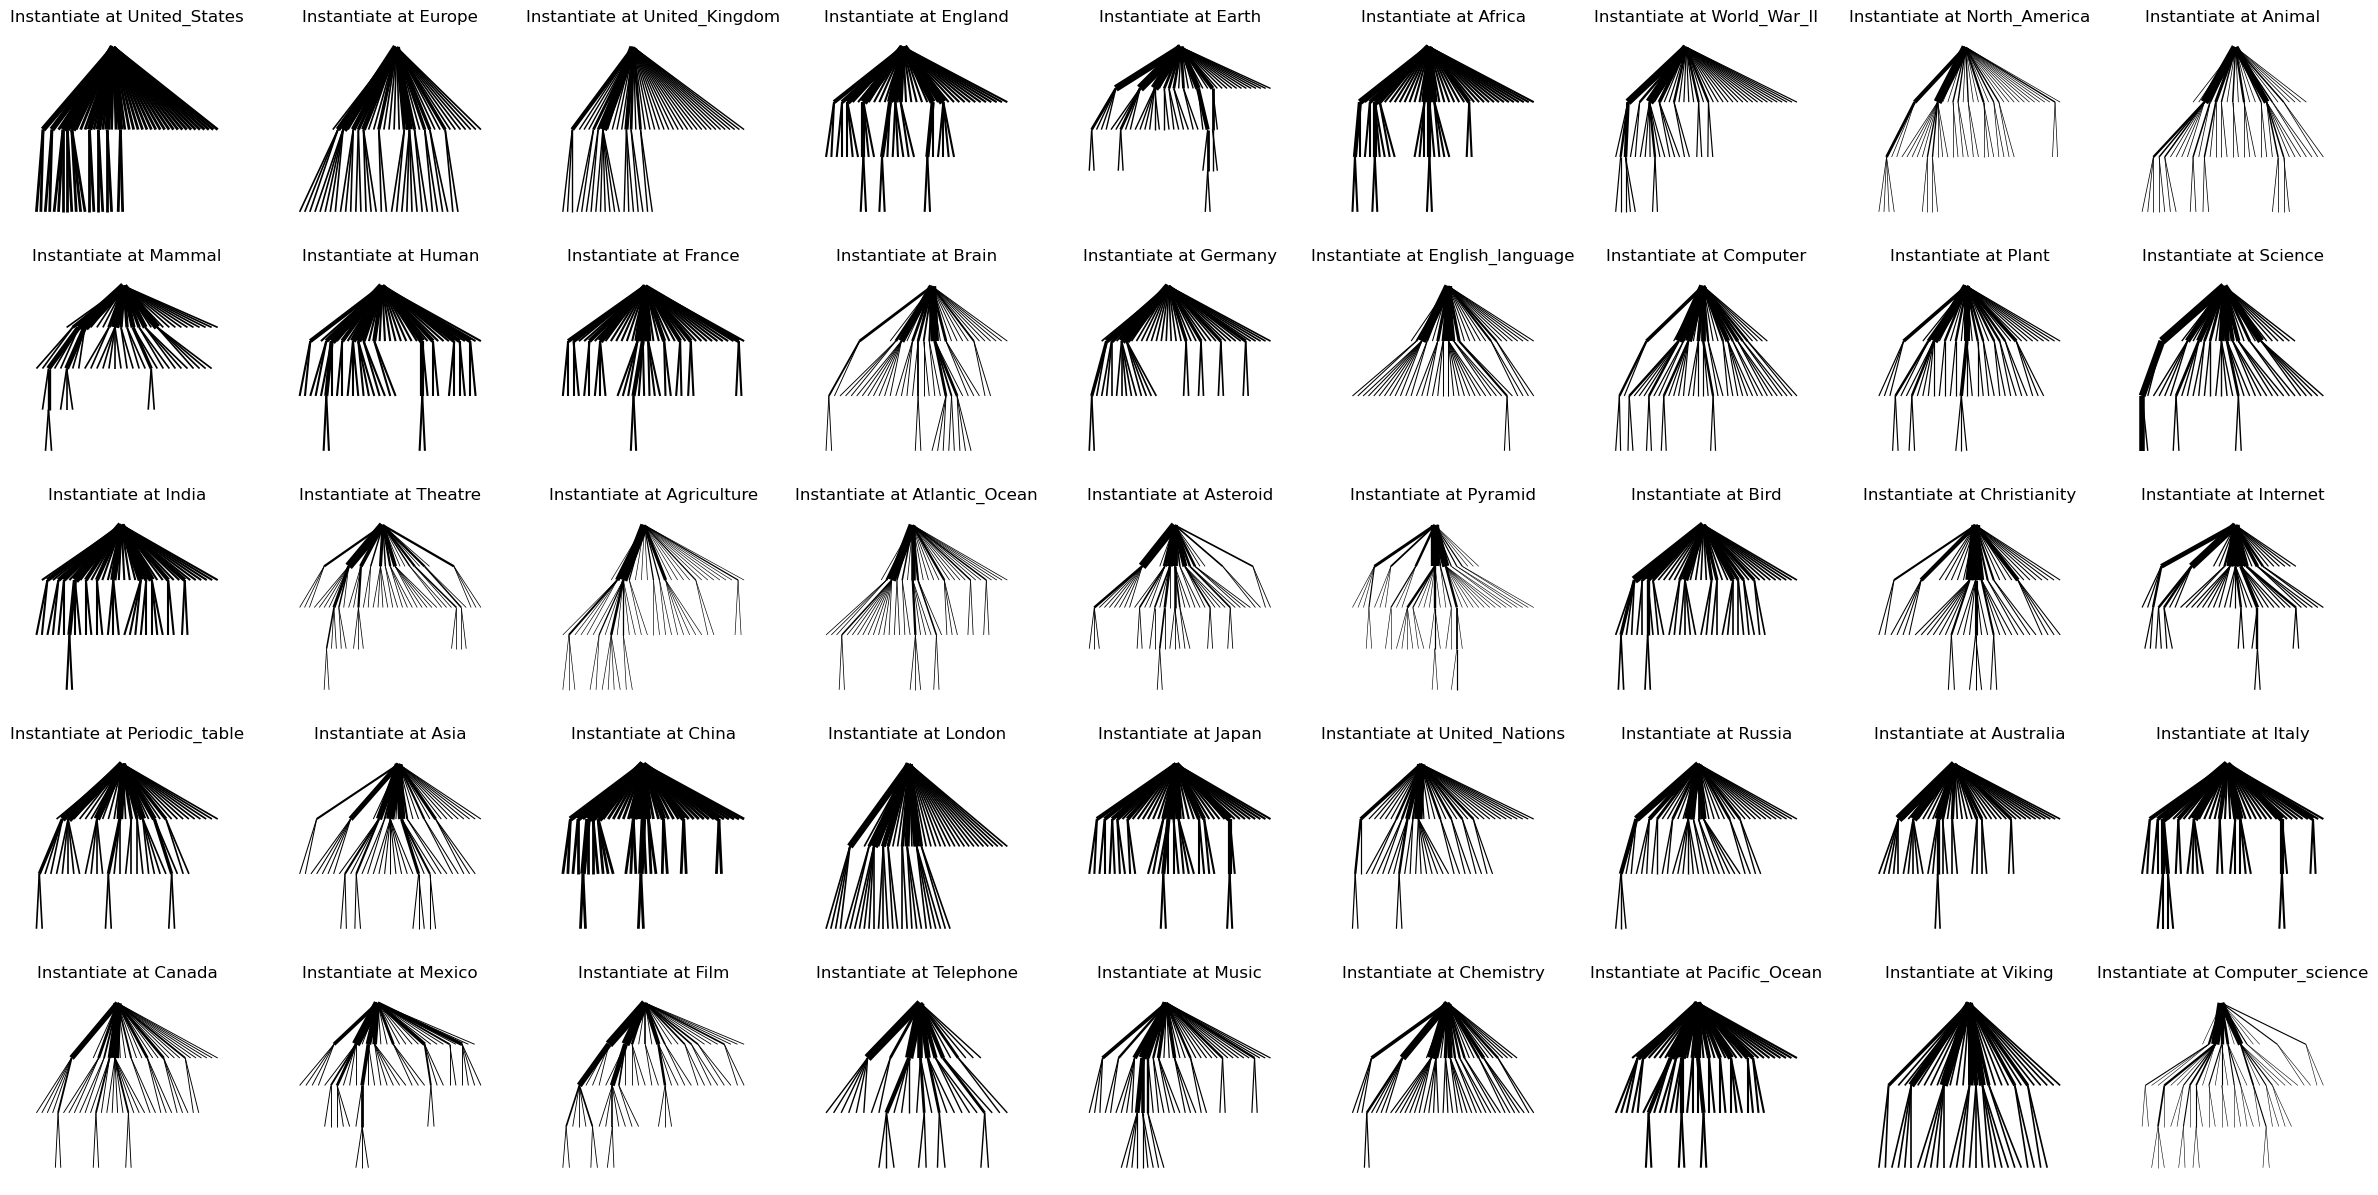

In [131]:
fig, axes = plt.subplots(5, 9, figsize=(30,15))#, facecolor=hex_to_rgb_add_alpha("FF5A5F", 0.3))
for i, node in enumerate(topk_nodes):
    
    G = example_tree_by_start_node[node]
    ax = axes[i // 9][i % 9]
    plot_flow_tree(G, f"Instantiate at {node}", ax, just_edges=True, no_title=False)
    if i == 44: break

plt.savefig("figures/wikispeedia/most_common_nodes_wikispeedia.png")
plt.show()        

### Reverse End Node